Import Libraries:

In [61]:
# Import libraries
import pandas as pd 
import numpy as np 
import math 
import statistics 
import matplotlib.pyplot as plt 

Initial parse and inspection:

In [62]:
# Import and inspect ES_2020-2025.csv 
raw_df = pd.read_csv(r".\Signal_data\ES_2020-2025.csv", sep=";", engine="python") 

# Remove first row of NaN data
raw_df = raw_df.iloc[1:].reset_index(drop=True) 

# Remove the imported but empty last column 
raw_df = raw_df.iloc[:,:-1]

# Display current header 
raw_df.head() 

,Quarter,Model_Classification_ID,Entry_Date_ISO,ES_Entry_Price,Direction,Exit_Date_ISO,ES_Exit_Price
0,q3-20,q3-20_1,2020-08-10,"3347,00",-1.0,2020-08-11,"3350,25"
1,q3-20,q3-20_2,2020-08-11,"3350,25",1.0,2020-08-19,"3388,75"
2,q3-20,q3-20_3,2020-08-19,"3388,75",-1.0,2020-08-20,"3370,25"
3,q3-20,q3-20_4,2020-08-20,"3370,25",1.0,2020-08-28,"3488,00"
4,q4-20,q4-20_1,2020-09-25,"3243,50",1.0,2020-09-28,"3291,00"


Edit column value types and tidy formatting:

In [63]:
# Change column names
columns = ["Quarter", "Model_Classification_ID", "Entry_Date", "Entry_Price", "Signal", "Exit_Date", "Exit_Price"]
raw_df.columns = columns 

# Change prices to floats 
raw_df["Entry_Price"] = raw_df["Entry_Price"].str.replace(",", ".").astype(float) 
raw_df["Exit_Price"] = raw_df["Exit_Price"].str.replace(",", ".").astype(float)

# Change date strings to datetime 
raw_df["Entry_Date"] = pd.to_datetime(raw_df["Entry_Date"])
raw_df["Exit_Date"] = pd.to_datetime(raw_df["Exit_Date"])

# Review data formatting
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Quarter                  117 non-null    object        
 1   Model_Classification_ID  117 non-null    object        
 2   Entry_Date               117 non-null    datetime64[ns]
 3   Entry_Price              117 non-null    float64       
 4   Signal                   117 non-null    float64       
 5   Exit_Date                117 non-null    datetime64[ns]
 6   Exit_Price               117 non-null    float64       
dtypes: datetime64[ns](2), float64(3), object(2)
memory usage: 6.5+ KB


Analyse number of trades, direction of trade and hit rate:

In [98]:
# Number of trades
Num_trades = len(raw_df) 
print(f"No. of trades: {Num_trades}")

# Add trade return and hit columns
raw_df["Returns"] = ((raw_df["Exit_Price"] - raw_df["Entry_Price"]) / raw_df["Entry_Price"]) * raw_df["Signal"]
raw_df["Hit"] = (raw_df["Returns"] > 0).astype(int)

# Count number of successful and unsuccessful trade
Num_hits = sum(raw_df.Hit) 
Num_misses = Num_trades - Num_hits
print(f"No. of hits: {Num_hits}")
print(f"No. of misses: {Num_misses}")
print(f"Hit rate: {(Num_hits/Num_trades)*100:.2f}%")

# Running profit/loss
raw_df["Cum_Returns"] = (1 + raw_df["Returns"]).cumprod()

# Running Equity Peak
running_peak = raw_df["Cum_Returns"].cummax() 

# Drawdown in pct 
raw_df["Drawdown"] = (raw_df["Cum_Returns"] - running_peak) / running_peak 

# Maximum drawdown experienced up to each point 
raw_df["Max_Drawdown"] = raw_df["Drawdown"].cummin() 

# Print results
max_dd = raw_df["Drawdown"].min() 
mu = raw_df["Returns"].mean() 
sigma = raw_df["Returns"].std()
print(f"Mean Return: {mu:,.3%}")
print(f"Std. Return: {sigma:,.3%}")
rf = 0.045 / 252
print(f"Sharpe: {((mu - rf) / sigma * math.sqrt(252)):.3}")
print(f"Maximum Drawdown: {abs(max_dd):,.2%}")


No. of trades: 117
No. of hits: 67
No. of misses: 50
Hit rate: 57.26%
Mean Return: 0.575%
Std. Return: 2.983%
Sharpe: 2.96
Maximum Drawdown: 17.00%


Analyse hit-rate per directional call, alongside general stats of each direction

In [65]:
# Assess bullish stats
bull_signals = (raw_df["Signal"] == 1).sum()
bull_rtn_mean = raw_df[raw_df["Signal"] == 1]["Returns"].mean()
bull_rtn_std = raw_df[raw_df["Signal"] == 1]["Returns"].std()

bull_hit = ((raw_df["Hit"] == 1) & (raw_df["Signal"] == 1)).sum()
bull_hit_rtn_mean = raw_df[((raw_df["Hit"] == 1) & (raw_df["Signal"] == 1))]["Returns"].mean()
bull_hit_rtn_std = raw_df[((raw_df["Hit"] == 1) & (raw_df["Signal"] == 1))]["Returns"].std()

bull_miss = ((raw_df["Hit"] == 0) & (raw_df["Signal"] == 1)).sum()
bull_miss_rtn_mean = raw_df[((raw_df["Hit"] == 0) & (raw_df["Signal"] == 1))]["Returns"].mean()
bull_miss_rtn_std = raw_df[((raw_df["Hit"] == 0) & (raw_df["Signal"] == 1))]["Returns"].std()

# Report results
print(f"-----###-----")
print(f"Bull General:")
print(f"Bullish signals: {bull_signals}")
print(f"Bull Return Mean: {bull_rtn_mean:.2f}")
print(f"Bull Return std: {bull_rtn_std:.2f}")

print(f"Hits:")
print(f"Bull hit count: {bull_hit}")
print(f"Bull hit mean: {bull_hit_rtn_mean:.2f}")
print(f"Bull hit std: {bull_hit_rtn_std:.2f}")

print(f"Misses:")
print(f"Bull miss count: {bull_miss}")
print(f"Bull miss mean: {bull_miss_rtn_mean:.2f}")
print(f"Bull miss std: {bull_miss_rtn_std:.2f}")

-----###-----
Bull General:
Bullish signals: 62
Bull Return Mean: 0.01
Bull Return std: 0.04
Hits:
Bull hit count: 37
Bull hit mean: 0.03
Bull hit std: 0.03
Misses:
Bull miss count: 25
Bull miss mean: -0.02
Bull miss std: 0.02


In [66]:
# Assess bearish stats
bear_signals = (raw_df["Signal"] == -1).sum()
bear_rtn_mean = raw_df[raw_df["Signal"] == -1]["Returns"].mean()
bear_rtn_std = raw_df[raw_df["Signal"] == -1]["Returns"].std()

bear_hit = ((raw_df["Hit"] == 1) & (raw_df["Signal"] == -1)).sum()
bear_hit_rtn_mean = raw_df[((raw_df["Hit"] == 1) & (raw_df["Signal"] == -1))]["Returns"].mean()
bear_hit_rtn_std = raw_df[((raw_df["Hit"] == 1) & (raw_df["Signal"] == -1))]["Returns"].std()

bear_miss = ((raw_df["Hit"] == 0) & (raw_df["Signal"] == -1)).sum()
bear_miss_rtn_mean = raw_df[((raw_df["Hit"] == 0) & (raw_df["Signal"] == -1))]["Returns"].mean()
bear_miss_rtn_std = raw_df[((raw_df["Hit"] == 0) & (raw_df["Signal"] == -1))]["Returns"].std()

# Report results
print(f"-----###-----")
print(f"Bear General:")
print(f"Bearish signals: {bear_signals}")
print(f"Bear Return Mean: {bear_rtn_mean:.2f}")
print(f"Bear Return std: {bear_rtn_std:.2f}")

print(f"Hits:")
print(f"Bear hit count: {bear_hit}")
print(f"Bear hit mean: {bear_hit_rtn_mean:.2f}")
print(f"Bear hit std: {bear_hit_rtn_std:.2f}")

print(f"Misses:")
print(f"Bear miss count: {bear_miss}")
print(f"Bear miss mean: {bear_miss_rtn_mean:.2f}")
print(f"Bear miss std: {bear_miss_rtn_std:.2f}")

-----###-----
Bear General:
Bearish signals: 55
Bear Return Mean: 0.00
Bear Return std: 0.02
Hits:
Bear hit count: 30
Bear hit mean: 0.02
Bear hit std: 0.01
Misses:
Bear miss count: 25
Bear miss mean: -0.02
Bear miss std: 0.01


Evaluate Strategy's Returns

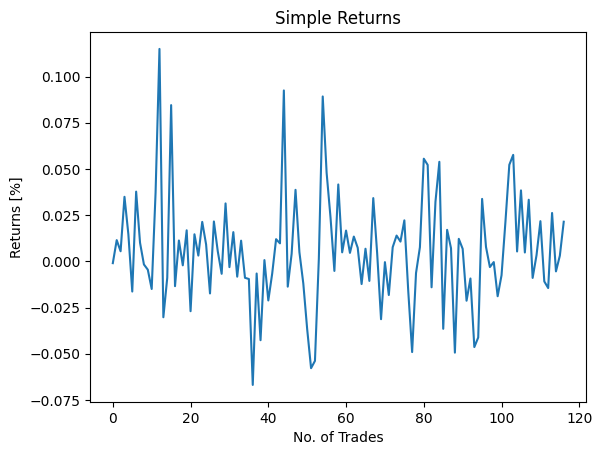

In [78]:
# Plot trade results 
plt.plot(raw_df['Returns'])
plt.xlabel('No. of Trades') 
plt.ylabel('Returns [%]') 
plt.title('Simple Returns')
plt.show() 

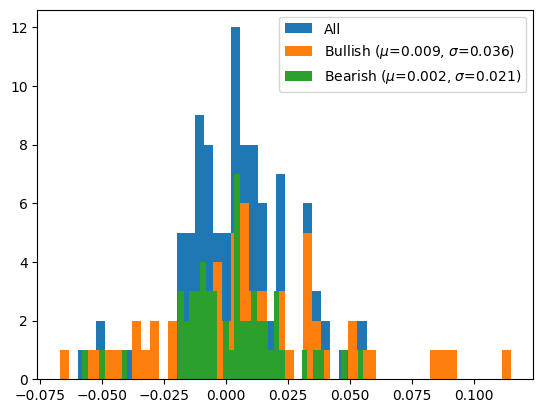

In [ ]:
# Plot trade results 
plt.hist(raw_df['Returns'], bins=50, label=fr"All ($\mu$={bull_rtn_mean:.3f}, $\sigma$={bull_rtn_std:.3f})")
plt.hist(raw_df[(raw_df["Signal"]==1)]['Returns'], bins=50, label=fr"Bullish ($\mu$={bull_rtn_mean:.3f}, $\sigma$={bull_rtn_std:.3f})")
plt.hist(raw_df[(raw_df["Signal"]==-1)]['Returns'], bins=50, label=fr"Bearish ($\mu$={bear_rtn_mean:.3f}, $\sigma$={bear_rtn_std:.3f})")
plt.legend() 
plt.show() 

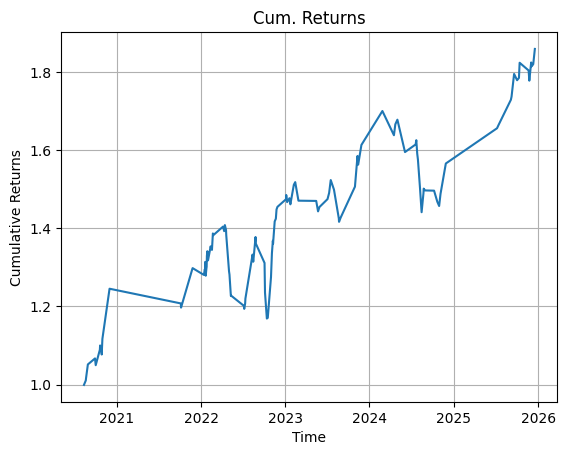

In [76]:
# Plot results
plt.plot(raw_df["Exit_Date"], raw_df["Cum_Returns"])
plt.xlabel('Time')
plt.ylabel('Cumulative Returns')
plt.title("Cum. Returns")
plt.grid() 
plt.show()

In [75]:
raw_df.head()

,Quarter,Model_Classification_ID,Entry_Date,Entry_Price,Signal,Exit_Date,Exit_Price,Returns,Hit,Cum_Returns,Drawdown,Max_Drawdown
0,q3-20,q3-20_1,2020-08-10,3347.00,-1.0,2020-08-11,3350.25,-0.000971,0,0.999029,0.0,0.0
1,q3-20,q3-20_2,2020-08-11,3350.25,1.0,2020-08-19,3388.75,0.011492,1,1.010510,0.0,0.0
2,q3-20,q3-20_3,2020-08-19,3388.75,-1.0,2020-08-20,3370.25,0.005459,1,1.016026,0.0,0.0
3,q3-20,q3-20_4,2020-08-20,3370.25,1.0,2020-08-28,3488.00,0.034938,1,1.051524,0.0,0.0
4,q4-20,q4-20_1,2020-09-25,3243.50,1.0,2020-09-28,3291.00,0.014645,1,1.066923,0.0,0.0


**Next Steps**:
- Analyse typical returns and volatility
- Acquire historical data for each instrument during trade windows to do daily settlement/returns analysis